## Project Title - EMIPredict AI - Intelligent Financial Risk Assessment Platform




### Domain - FinTech and Banking



### Problem Statement

Build a comprehensive financial risk assessment platform that integrates machine learning models to create an interactive web application for EMI prediction.

Nowadays, people struggle to pay EMI due to poor financial planning and inadequate risk assessment. This project aims to solve this critical issue by providing data-driven insights for better loan decisions.

The platform should deliver dual ML problem solving: Classification (EMI eligibility) and Regression (maximum EMI amount) 
Real-time financial risk assessment using 400,000 records.
Advanced feature engineering from 22 financial and demographic variables.
Streamlit Cloud deployment for production-ready access.
Complete CRUD operations for financial data management.


### Business Use Cases

**Financial Institutions**:
Automate loan approval processes and reduce manual underwriting time by 80%
Implement risk-based pricing strategies for different EMI scenarios
Real-time eligibility assessment for walk-in customers

**FinTech Companies**:
Instant EMI eligibility checks for digital lending platforms
Integration with mobile apps for pre-qualification services
Automated risk scoring for loan applications

**Banks and Credit Agencies**:
Data-driven loan amount recommendations based on financial capacity
Portfolio risk management and default prediction
Regulatory compliance through documented decision processes

**Loan Officers and Underwriters**:
AI-powered recommendations for loan approval decisions
Comprehensive financial profile analysis in seconds
Historical performance tracking and model accuracy monitoring


### Approach


**Data Loading and Preprocessing**

Load the provided dataset of 400,000 realistic financial records across 5 EMI scenarios
Implement comprehensive data cleaning for missing values, inconsistencies, and duplicates
Apply data quality assessment and validation checks
Create train-test-validation splits for model development

**Exploratory Data Analysis**

Analyze EMI eligibility distribution patterns across different lending scenarios
Study correlation between financial variables and loan approval rates
Investigate demographic patterns and risk factor relationships
Generate comprehensive statistical summaries and business insights

**Feature Engineering**

Create derived financial ratios (debt-to-income, expense-to-income, affordability ratios)
Generate risk scoring features based on credit history and employment stability
Apply categorical encoding and numerical feature scaling
Develop interaction features between key financial variables

**Machine Learning Model Development**

Classification Models (EMI Eligibility Prediction):
Logistic Regression for baseline interpretable results
Random Forest Classifier for feature importance analysis
XGBoost Classifier for high-performance gradient boosting
Model evaluation using accuracy, precision, recall, F1-score
Best performing classification model will be selected for final deployment
Regression Models (Maximum EMI Amount Prediction):
Linear Regression for baseline performance
Random Forest Regressor for ensemble-based predictions
XGBoost Regressor for advanced gradient boosting
Model evaluation using MSE, MAE, R-squared
Best performing regression model will be selected for final deployment

**Model Selection**

Train minimum 3 models each for classification and regression problems
Log comprehensive model parameters, hyperparameters, and performance metrics for all models
Create systematic artifact storage for models, visualizations, and datasets
Select best performing models based on evaluation metrics for production deployment
Implement model registry for version control and selected model storage

**Streamlit Application Development**

Multi-page web application with intuitive user interface
Real-time prediction capabilities for both classification and regression
Interactive data exploration and visualization components
Administrative interface for data management operations

**Cloud Deployment and Production**

Deploy complete application on Streamlit Cloud platform
Implement responsive design for cross-platform accessibility
Ensure proper error handling and user feedback mechanisms


**Dataflow and Architecture Components**:

**Data Layer**: Structured financial data following domain rules

**Processing Layer**: Data cleaning, feature engineering, and ML pipelines

**Model Layer**: Classification and regression models

**Application Layer**: Multi-page Streamlit web application with real-time predictions

**Deployment Layer**: Streamlit Cloud hosting


In [1]:
# Import required libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pickle                                                                         
import xgboost as xgb                                                                  
from sklearn.preprocessing import StandardScaler                                       
from sklearn.preprocessing import LabelEncoder                                         
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression                                    
from sklearn.ensemble import RandomForestClassifier                                    
from sklearn.tree import DecisionTreeClassifier                                        
from xgboost  import XGBClassifier                                                     
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  

from sklearn.linear_model import LinearRegression,  Ridge, Lasso                
from sklearn.tree import DecisionTreeRegressor                                  
from sklearn.ensemble import RandomForestRegressor                              
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error   

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")                                                      

/Users/biplab/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Load and Read the CSV File

In [2]:
emi = pd.read_csv("/Users/biplab/Downloads/emi_prediction_dataset.csv")
emi.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [3]:
emi.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='object')

### Dataset Description



**Dataset Scale**:

Total Records: 400,000 financial profiles

Input Features: 22 comprehensive variables

Target Variables: 2 (Classification + Regression)

EMI Scenarios: 5 lending categories with realistic distributions

**EMI Scenario Distribution**:

E-commerce Shopping EMI (80,000 records) - Amount: 10K-200K, Tenure: 3-24 months

Home Appliances EMI (80,000 records) - Amount: 20K-300K, Tenure: 6-36 months

Vehicle EMI (80,000 records) - Amount: 80K-1500K, Tenure: 12-84 months

Personal Loan EMI (80,000 records) - Amount: 50K-1000K, Tenure: 12-60 months

Education EMI (80,000 records) - Amount: 50K-500K, Tenure: 6-48 months

### Dataset Explanation



**Input Features (22 Variables):**
    
**Personal Demographics:**

age: Customer age (25-60 years)

gender: Gender classification (Male/Female)

marital_status: Marital status (Single/Married)

education: Educational qualification (High School/Graduate/Post Graduate/Professional)

**Employment and Income:**

monthly_salary: Monthly gross salary (15K-200K INR)

employment_type: Employment category (Private/Government/Self-employed)

years_of_employment: Work experience duration

company_type: Organization size and type

**Housing and Family:**

house_type: Residential ownership status (Rented/Own/Family)

monthly_rent: Monthly rental expenses

family_size: Total household members

dependents: Number of financial dependents

**Monthly Financial Obligations:**

school_fees: Educational expenses for dependents

college_fees: Higher education costs

travel_expenses: Monthly transportation costs

groceries_utilities: Essential living expenses

other_monthly_expenses: Miscellaneous financial obligations

**Financial Status and Credit History:**

existing_loans: Current loan obligations status

current_emi_amount: Existing monthly EMI burden

credit_score: Credit worthiness score (300-850)

bank_balance: Current account balance

emergency_fund: Available emergency savings

**Loan Application Details:**

emi_scenario: Type of EMI application (5 categories)

requested_amount: Desired loan amount

requested_tenure: Preferred repayment period in months

**Target Variables:**

**Classification Target:**

emi_eligibility: Primary classification target with 3 classes

Eligible: Low risk, comfortable EMI affordability

High_Risk: Marginal case, requires higher interest rates

Not_Eligible: High risk, loan not recommended

**Regression Target:**

max_monthly_emi: Primary regression target

Continuous variable representing maximum safe monthly EMI amount (500-50000 INR)

Calculated using comprehensive financial capacity analysis


In [4]:
emi.describe()

,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
count,404800.000000,402374.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,402380.000000,402449.000000,4.048000e+05,404800.000000,404800.000000
mean,5.364079,5828.446490,2.940425,1.940425,4624.575593,4066.253706,5687.497777,12804.999506,7119.309783,4543.407609,700.856223,96769.051731,3.708554e+05,29.126677,6763.602156
std,6.079135,8648.604639,1.075199,1.075199,5061.074401,7319.344289,3392.671132,6993.853745,4510.447300,7034.901139,88.435548,81373.053976,3.451945e+05,18.100854,7741.263317
min,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,600.000000,1800.000000,600.000000,0.000000,0.000000,1400.000000,1.000000e+04,3.000000,500.000000
25%,1.200000,0.000000,2.000000,1.000000,0.000000,0.000000,3200.000000,7700.000000,3800.000000,0.000000,654.000000,38400.000000,1.240000e+05,15.000000,500.000000
50%,3.200000,0.000000,3.000000,2.000000,3000.000000,0.000000,4900.000000,11400.000000,6000.000000,0.000000,701.000000,74000.000000,2.360000e+05,25.000000,4211.200000
75%,7.200000,10600.000000,4.000000,3.000000,9000.000000,6500.000000,7400.000000,16400.000000,9300.000000,8000.000000,748.000000,130600.000000,4.940000e+05,40.000000,9792.000000
max,36.000000,80000.000000,5.000000,4.000000,15000.000000,25000.000000,30300.000000,71200.000000,42900.000000,56300.000000,1200.000000,891500.000000,1.500000e+06,84.000000,91040.400000


In [5]:
emi.value_counts().sum()

392920

Check the Datasets Informations.

In [6]:
emi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

Change  the Datasets Columns Name Lower Case To Upper Case.

In [7]:
emi.columns = emi.columns.str.replace("_"," ").str.title()

emi.columns

Index(['Age', 'Gender', 'Marital Status', 'Education', 'Monthly Salary',
       'Employment Type', 'Years Of Employment', 'Company Type', 'House Type',
       'Monthly Rent', 'Family Size', 'Dependents', 'School Fees',
       'College Fees', 'Travel Expenses', 'Groceries Utilities',
       'Other Monthly Expenses', 'Existing Loans', 'Current Emi Amount',
       'Credit Score', 'Bank Balance', 'Emergency Fund', 'Emi Scenario',
       'Requested Amount', 'Requested Tenure', 'Emi Eligibility',
       'Max Monthly Emi'],
      dtype='object')

Check the Null Values in Data sets.

In [8]:
if emi.isnull().values.any():
    print(emi.isnull().sum() [emi.isnull().sum() > 0])
else:
    print("No Null Values")


Education         2404
Monthly Rent      2426
Credit Score      2420
Bank Balance      2426
Emergency Fund    2351
dtype: int64


Check the Datasets DataTypes.

In [9]:
emi.dtypes

Age                        object
Gender                     object
Marital Status             object
Education                  object
Monthly Salary             object
Employment Type            object
Years Of Employment       float64
Company Type               object
House Type                 object
Monthly Rent              float64
Family Size                 int64
Dependents                  int64
School Fees               float64
College Fees              float64
Travel Expenses           float64
Groceries Utilities       float64
Other Monthly Expenses    float64
Existing Loans             object
Current Emi Amount        float64
Credit Score              float64
Bank Balance               object
Emergency Fund            float64
Emi Scenario               object
Requested Amount          float64
Requested Tenure            int64
Emi Eligibility            object
Max Monthly Emi           float64
dtype: object

Change the Mismatch Datatypes Columns.

In [10]:
emi['Age'] = pd.to_numeric(emi['Age'] , errors='coerce')
emi['Monthly Salary'] = pd.to_numeric(emi['Monthly Salary'], errors='coerce')
emi["Bank Balance"] = pd.to_numeric(emi["Bank Balance"], errors='coerce')
emi["Monthly Salary"].head(1)

0    82600.0
Name: Monthly Salary, dtype: float64

Fill the Null Values use Back Fill or Forward Fill.

In [11]:
emi[["Education", "Monthly Rent", "Credit Score", "Bank Balance", "Emergency Fund"]] = emi[["Education", "Monthly Rent", "Credit Score", "Bank Balance", "Emergency Fund"]].fillna(method="bfill")


In [12]:
emi[["Education", "Monthly Rent", "Credit Score", "Bank Balance", "Emergency Fund"]] = emi[["Education", "Monthly Rent", "Credit Score", "Bank Balance", "Emergency Fund"]].fillna(method="ffill")

In [13]:
emi[['Age', 'Monthly Salary']] = emi[['Age', 'Monthly Salary']].fillna(emi[['Age', 'Monthly Salary']].mean())

Checking Null values again if there are exists any

In [14]:
if emi.isnull().values.any():
    print(emi.isnull().sum() [emi.isnull().sum() > 0])
else:
    print("No Null Values")

No Null Values


Save the Cleaned CSV files.

In [15]:
import os
print(os.getcwd())


/Users/biplab/Downloads/EMI Prediction - Demo


In [16]:
emi.to_csv("EMI Prediction Clean.csv", index=False)

In [17]:
import pandas as pd

df = pd.read_csv('/Users/biplab/Downloads/EMI Prediction - Demo/EMI Prediction Clean.csv')
df.head()

,Age,Gender,Marital Status,Education,Monthly Salary,Employment Type,Years Of Employment,Company Type,House Type,Monthly Rent,...,Existing Loans,Current Emi Amount,Credit Score,Bank Balance,Emergency Fund,Emi Scenario,Requested Amount,Requested Tenure,Emi Eligibility,Max Monthly Emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


Removing Outliers

In [18]:
Q1 = df['Max Monthly Emi'].quantile(0.25)
Q3 = df['Max Monthly Emi'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df['Max Monthly Emi'] < (Q1 - 1.5*IQR)) | (df['Max Monthly Emi'] > (Q3 + 1.5*IQR)))]
print(df_clean.shape)


(387532, 27)


In [19]:
df_clean.columns

Index(['Age', 'Gender', 'Marital Status', 'Education', 'Monthly Salary',
       'Employment Type', 'Years Of Employment', 'Company Type', 'House Type',
       'Monthly Rent', 'Family Size', 'Dependents', 'School Fees',
       'College Fees', 'Travel Expenses', 'Groceries Utilities',
       'Other Monthly Expenses', 'Existing Loans', 'Current Emi Amount',
       'Credit Score', 'Bank Balance', 'Emergency Fund', 'Emi Scenario',
       'Requested Amount', 'Requested Tenure', 'Emi Eligibility',
       'Max Monthly Emi'],
      dtype='object')

In [20]:
df_clean['Dependents']

0         2
1         1
3         4
4         3
5         3
         ..
404795    3
404796    4
404797    0
404798    3
404799    1
Name: Dependents, Length: 387532, dtype: int64

In [21]:
df_clean.drop(['Dependents', 'School Fees', 'College Fees', 'Travel Expenses', 'Groceries Utilities', 'Emergency Fund', 'Requested Tenure'], axis=1, inplace=True)


In [22]:
df_clean.columns

Index(['Age', 'Gender', 'Marital Status', 'Education', 'Monthly Salary',
       'Employment Type', 'Years Of Employment', 'Company Type', 'House Type',
       'Monthly Rent', 'Family Size', 'Other Monthly Expenses',
       'Existing Loans', 'Current Emi Amount', 'Credit Score', 'Bank Balance',
       'Emi Scenario', 'Requested Amount', 'Emi Eligibility',
       'Max Monthly Emi'],
      dtype='object')

In [23]:
df_clean.to_csv("EMI Prediction1.csv", index=False)

In [24]:
df_clean.head()

,Age,Gender,Marital Status,Education,Monthly Salary,Employment Type,Years Of Employment,Company Type,House Type,Monthly Rent,Family Size,Other Monthly Expenses,Existing Loans,Current Emi Amount,Credit Score,Bank Balance,Emi Scenario,Requested Amount,Emi Eligibility,Max Monthly Emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,3,13200.0,Yes,23700.0,660.0,303200.0,Personal Loan EMI,850000.0,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,2,3500.0,Yes,4100.0,714.0,92500.0,E-commerce Shopping EMI,128000.0,Not_Eligible,700.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,5,7900.0,No,0.0,685.0,440900.0,Vehicle EMI,304000.0,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,4,8100.0,No,0.0,770.0,97300.0,Home Appliances EMI,252000.0,Not_Eligible,500.0
5,38.0,Male,Married,High School,38800.0,Government,5.0,Large Indian,Rented,13500.0,4,6700.0,No,0.0,792.0,260800.0,Vehicle EMI,1257000.0,Not_Eligible,500.0


## EDA

In [25]:
df = pd.read_csv("/Users/biplab/Downloads/EMI Prediction - Demo/EMI Prediction Clean.csv")
df.shape

(404800, 27)

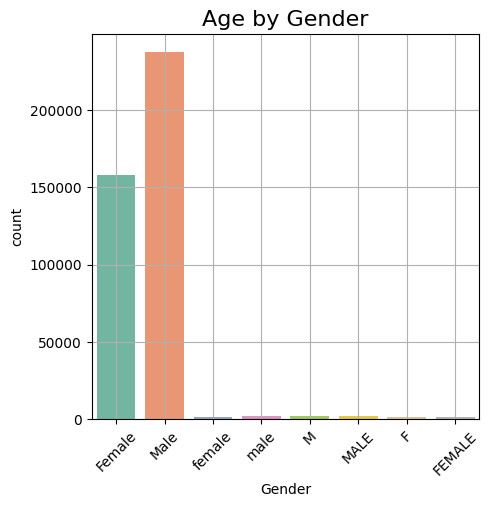

In [26]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x="Gender", palette="Set2")
plt.title("Age by Gender", fontsize=16)
plt.grid()
plt.xticks(rotation=45)
plt.show()


Text(0.5, 1.0, 'Educations')

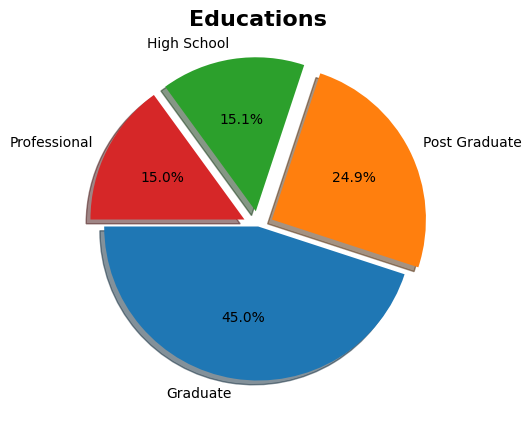

In [27]:
education = df['Education'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(education, labels=education.index, autopct="%1.1f%%", startangle=180, shadow=True, explode=[0,0.1,0.1,0.1])
plt.title("Educations", fontsize=16, fontweight='bold')




In [28]:
ages = df['Age'].value_counts()
ages

Age
38.000000    120508
32.000000    100424
48.000000     80388
27.000000     59852
58.000000     40408
37.000000       490
39.000000       480
33.000000       445
31.000000       393
49.000000       320
47.000000       297
28.000000       230
26.000000       211
59.000000       183
57.000000       168
38.875832         3
Name: count, dtype: int64

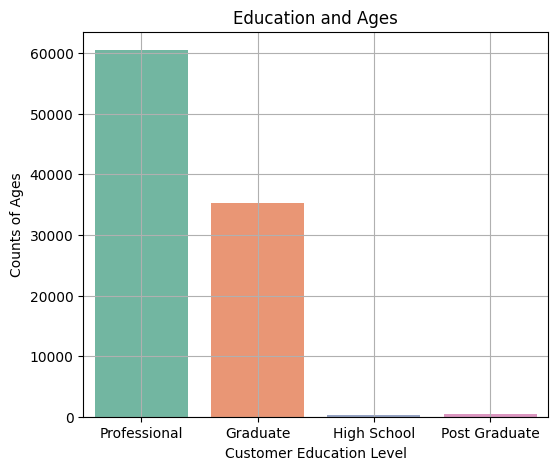

In [29]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='Education', y=ages, ci=None, palette='Set2')
plt.title('Education and Ages')
plt.ylabel('Counts of Ages')
plt.xlabel('Customer Education Level')
plt.grid()
plt.show()

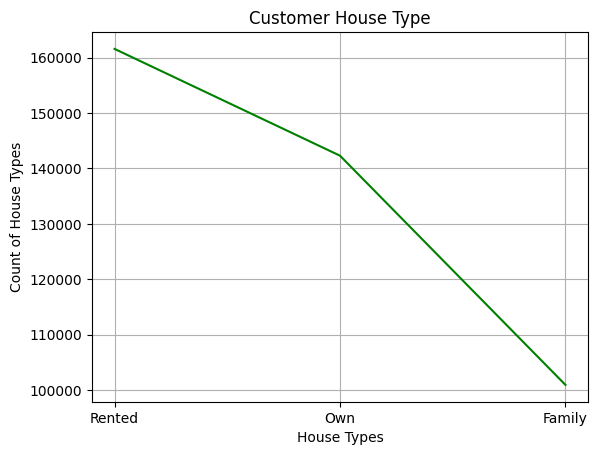

In [30]:
house_counts = df['House Type'].value_counts().reset_index()
house_counts.columns = ['House Type', 'Count']

sns.lineplot(data=house_counts, x='House Type', y='Count', color='Green')
plt.title('Customer House Type')
plt.xlabel('House Types')
plt.ylabel('Count of House Types')
plt.grid()
plt.show()


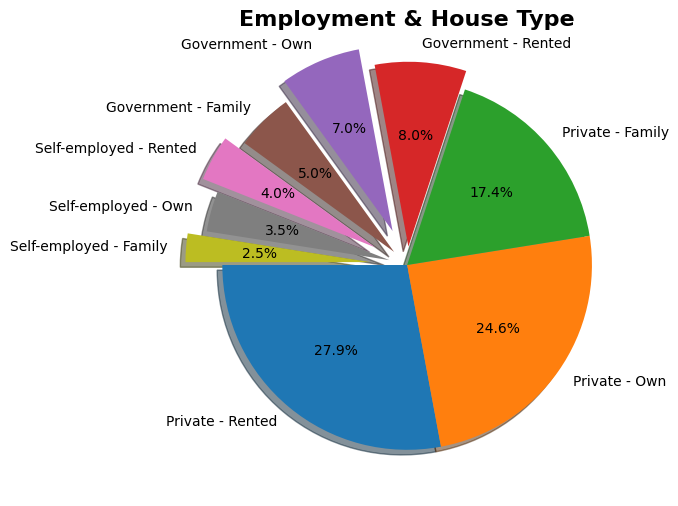

In [31]:
employe = df[['Employment Type', 'House Type']].value_counts()
employe = employe.reset_index(name='Count')

plt.figure(figsize=(6,6))
plt.pie(employe['Count'], labels=employe[['Employment Type','House Type']].astype(str).agg(' - '.join, axis=1),
        autopct="%1.1f%%", startangle=180, shadow=True, explode=[0, 0, 0, 0.1, 0.2, 0.1, 0.2, 0.1, 0.2])
plt.title("Employment & House Type", fontsize=16, fontweight='bold')
plt.show()


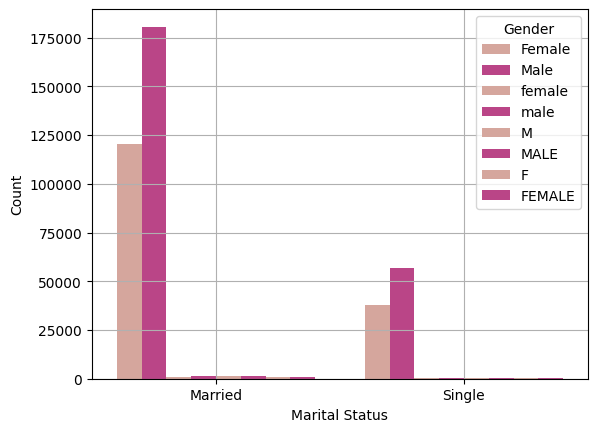

In [32]:
sns.countplot(data=df, x='Marital Status', hue='Gender', palette=["#DE9F94",  "#CD328A"])
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.grid()
plt.show()


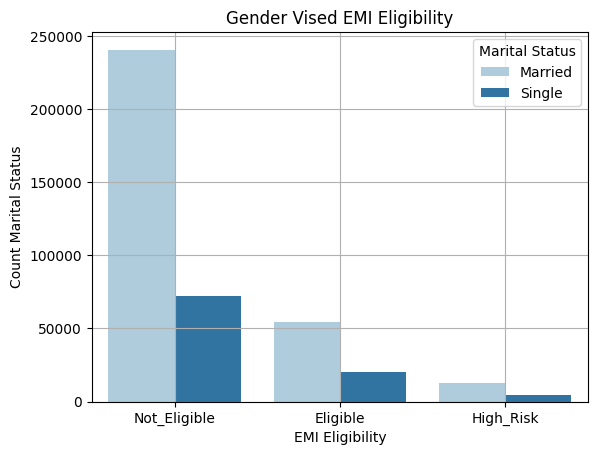

In [33]:
sns.countplot(data=df, x='Emi Eligibility', hue='Marital Status', palette='Paired')
plt.title('Gender Vised EMI Eligibility')
plt.xlabel('EMI Eligibility')
plt.ylabel('Count Marital Status')
plt.grid()
plt.show()

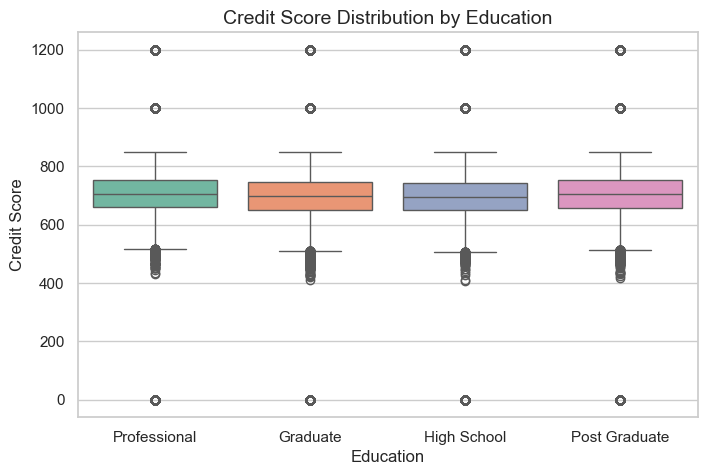

In [34]:
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Education', y='Credit Score', palette='Set2')
plt.title('Credit Score Distribution by Education', fontsize=14)
plt.xlabel('Education')
plt.ylabel('Credit Score')
plt.show()


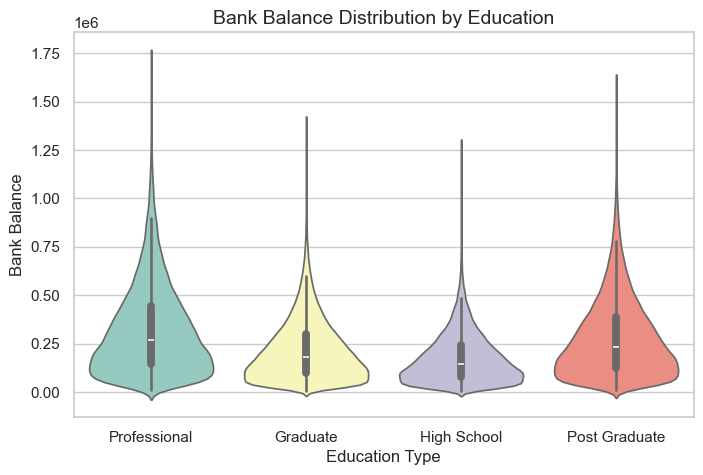

In [35]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Education', y='Bank Balance', palette='Set3')
plt.title('Bank Balance Distribution by Education', fontsize=14)
plt.xlabel('Education Type')
plt.ylabel('Bank Balance')
plt.show()



Remove Outerlines in datasets

In [36]:
Q1 = df['Max Monthly Emi'].quantile(0.25)
Q3 = df['Max Monthly Emi'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df['Max Monthly Emi'] < (Q1 - 1.5*IQR)) | (df['Max Monthly Emi'] > (Q3 + 1.5*IQR)))]
print(df_clean.shape)

(387532, 27)


Change the categorical columns in to Label encoder

In [37]:
categorical_cols = ['Gender', 'Marital Status', 'Education', 
                    'Employment Type', 'Company Type', 'House Type', 
                    'Emi Scenario','Existing Loans', 'Emi Eligibility']

numeric_cols = ['Age', 'Monthly Salary', 'Years Of Employment', 'Monthly Rent', 
                'Family Size', 'Dependents', 'School Fees', 'College Fees', 
                'Travel Expenses', 'Groceries Utilities', 'Other Monthly Expenses', 
                'Existing Loans', 'Current Emi Amount', 'Credit Score', 'Bank Balance', 
                'Emergency Fund', 'Requested Amount', 'Requested Tenure', 'Max Monthly Emi']
 

In [38]:
X_encoded = pd.get_dummies(df_clean[numeric_cols + categorical_cols], 
                           columns=categorical_cols, drop_first=True)

In [39]:
le = LabelEncoder()


for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print(df)

         Age  Gender Marital Status      Education  Monthly Salary  \
0       38.0  Female        Married   Professional         82600.0   
1       38.0  Female        Married       Graduate         21500.0   
2       38.0    Male        Married   Professional         86100.0   
3       58.0  Female        Married    High School         66800.0   
4       48.0  Female        Married   Professional         57300.0   
...      ...     ...            ...            ...             ...   
404795  27.0    Male        Married       Graduate         32400.0   
404796  38.0    Male        Married  Post Graduate         49200.0   
404797  32.0    Male         Single       Graduate         25700.0   
404798  48.0    Male        Married       Graduate         47200.0   
404799  38.0  FEMALE        Married       Graduate         34900.0   

       Employment Type  Years Of Employment  Company Type House Type  \
0              Private                  0.9      Mid-size     Rented   
1              

In [40]:
X_encoded.columns

Index(['Age', 'Monthly Salary', 'Years Of Employment', 'Monthly Rent',
       'Family Size', 'Dependents', 'School Fees', 'College Fees',
       'Travel Expenses', 'Groceries Utilities', 'Other Monthly Expenses',
       'Current Emi Amount', 'Credit Score', 'Bank Balance', 'Emergency Fund',
       'Requested Amount', 'Requested Tenure', 'Max Monthly Emi',
       'Gender_FEMALE', 'Gender_Female', 'Gender_M', 'Gender_MALE',
       'Gender_Male', 'Gender_female', 'Gender_male', 'Marital Status_Single',
       'Education_High School', 'Education_Post Graduate',
       'Education_Professional', 'Employment Type_Private',
       'Employment Type_Self-employed', 'Company Type_MNC',
       'Company Type_Mid-size', 'Company Type_Small', 'Company Type_Startup',
       'House Type_Own', 'House Type_Rented', 'Emi Scenario_Education EMI',
       'Emi Scenario_Home Appliances EMI', 'Emi Scenario_Personal Loan EMI',
       'Emi Scenario_Vehicle EMI', 'Existing Loans_Yes', 'Existing Loans_Yes',
      

Make Train and Target data into X and y

In [41]:
X = X_encoded.drop(['Emi Eligibility_High_Risk', 'Emi Eligibility_Not_Eligible'], axis=1)
y = df_clean['Emi Eligibility']  


Split the dataset into train and test set by 70-30 ratio

In [42]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Classification Models

## Random Forest Classifier

Model Building

In [43]:
model = RandomForestClassifier(random_state=42)

Model Train and Predictions

In [46]:
model.fit(x_train, y_train)
y_predict = model.predict(x_test)

Model Evaluation

In [47]:
rf_acc = accuracy_score(y_test, y_predict)
rf_report = classification_report(y_test, y_predict)
rf_cm = confusion_matrix(y_test, y_predict)


print(f"Accuracy Score: {rf_acc:.4f}")
print("\nClassification Report:\n", rf_report)
print("\nConfusion Matrix:\n", rf_cm)


Accuracy Score: 0.9477

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93     18247
           1       0.80      0.03      0.05      4846
           2       0.95      1.00      0.98     93167

    accuracy                           0.95    116260
   macro avg       0.89      0.65      0.65    116260
weighted avg       0.94      0.95      0.93    116260


Confusion Matrix:
 [[17021    26  1200]
 [ 1402   124  3320]
 [  127     5 93035]]


Actual data vs Predicted data Comparison

In [48]:
prediction = pd.DataFrame({
    'Actual' : y_test.values,
    'Predict' : y_predict
})

prediction.iloc[10:35]

,Actual,Predict
10,2,2
11,2,2
12,2,2
13,2,2
14,2,2
15,2,2
16,2,2
17,2,2
18,2,2
19,2,2


## Decision Tree Classifier

Model Building 

In [49]:
model = DecisionTreeClassifier(random_state=42)

Model Train and Prediction 

In [50]:
model.fit(x_train, y_train)
y_predict = model.predict(x_test)

Model Evaluation

In [51]:
dt_acc = accuracy_score(y_test, y_predict)
dt_reports = classification_report(y_test, y_predict)
dt_cms = confusion_matrix(y_test, y_predict)

print(f"Accuracy Score: {dt_acc:.4f}")
print("\nClassification Report:\n", dt_reports)
print("\nConfusion Matrix:\n", dt_cms)


Accuracy Score: 0.9758

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96     18247
           1       0.71      0.72      0.72      4846
           2       0.99      0.99      0.99     93167

    accuracy                           0.98    116260
   macro avg       0.89      0.89      0.89    116260
weighted avg       0.98      0.98      0.98    116260


Confusion Matrix:
 [[17538   679    30]
 [  654  3479   713]
 [   14   719 92434]]


Actual data vs Predicted data Comparison

In [52]:
predic_dec = pd.DataFrame({
    'Actual' : y_test.values,
    'Predict' : y_predict
})

predic_dec.iloc[15:30]

,Actual,Predict
15,2,2
16,2,2
17,2,2
18,2,2
19,2,2
20,2,2
21,2,2
22,0,0
23,0,0
24,2,2


## XGBoost Classifier 

In [53]:
df_xgb = pd.read_csv("/Users/biplab/Downloads/EMI Prediction - Demo/EMI Prediction Clean.csv")

In [54]:
#Remove outliers

Q1 = df_xgb['Max Monthly Emi'].quantile(0.25)
Q3 = df_xgb['Max Monthly Emi'].quantile(0.75)
IQR = Q3 - Q1

df_clean_x = df_xgb[~((df_xgb['Max Monthly Emi'] < (Q1 - 1.5*IQR)) | (df_xgb['Max Monthly Emi'] > (Q3 + 1.5*IQR)))]
print(df_clean_x.shape)

(387532, 27)


In [55]:
numeric_cols = ['Age', 'Monthly Salary', 'Years Of Employment', 'Monthly Rent', 
                'Family Size', 'Dependents', 'School Fees', 'College Fees', 
                'Travel Expenses', 'Groceries Utilities', 'Other Monthly Expenses', 
                'Current Emi Amount', 'Credit Score', 'Bank Balance', 
                'Emergency Fund', 'Requested Amount', 'Requested Tenure', 
                'Max Monthly Emi']

categorical_cols = ['Gender', 'Marital Status', 'Education', 
                    'Employment Type', 'Company Type', 'House Type', 
                    'Emi Scenario','Existing Loans']

In [56]:
categorical_cols = ['Gender', 'Marital Status', 'Education', 
                    'Employment Type', 'Company Type', 'House Type', 
                    'Emi Scenario','Existing Loans', 'Emi Eligibility']


le = LabelEncoder()


for col in categorical_cols:
    df_clean_x[col] = le.fit_transform(df_clean_x[col])

print(df_clean_x)

         Age  Gender  Marital Status  Education  Monthly Salary  \
0       38.0       2               0          3         82600.0   
1       38.0       2               0          0         21500.0   
3       58.0       2               0          1         66800.0   
4       48.0       2               0          3         57300.0   
5       38.0       5               0          1         38800.0   
...      ...     ...             ...        ...             ...   
404795  27.0       5               0          0         32400.0   
404796  38.0       5               0          2         49200.0   
404797  32.0       5               1          0         25700.0   
404798  48.0       5               0          0         47200.0   
404799  38.0       1               0          0         34900.0   

        Employment Type  Years Of Employment  Company Type  House Type  \
0                     1                  0.9             2           2   
1                     1                  7.0   

In [57]:
X_encoded = pd.get_dummies(df_clean_x[numeric_cols + categorical_cols], 
                   columns=categorical_cols, drop_first=True)


In [58]:
X = df_clean_x.drop('Emi Eligibility', axis=1)
y = df_clean_x['Emi Eligibility']  


In [59]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [60]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [61]:
model.fit(x_train, y_train)
y_predict = model.predict(x_test)


In [62]:
xgb_acc = accuracy_score(y_test, y_predict)
xgb_reports = classification_report(y_test, y_predict)
xgb_cms = confusion_matrix(y_test, y_predict)

print(f"Accuracy Score: {xgb_acc:.4f}")
print("\nClassification Report:\n", xgb_reports)
print("\nConfusion Matrix:\n", xgb_cms)



Accuracy Score: 0.9899

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     18247
           1       0.90      0.85      0.87      4846
           2       1.00      1.00      1.00     93167

    accuracy                           0.99    116260
   macro avg       0.96      0.94      0.95    116260
weighted avg       0.99      0.99      0.99    116260


Confusion Matrix:
 [[18003   242     2]
 [  319  4105   422]
 [    0   191 92976]]


In [63]:
prediction_xgb = pd.DataFrame({
    'Actual' : y_test.values,
    'Predict' : y_predict
})

prediction_xgb.iloc[20:30]

,Actual,Predict
20,2,2
21,2,2
22,0,0
23,0,0
24,2,2
25,2,2
26,2,2
27,1,1
28,2,2
29,2,2


Saving the best model as per the highest Accuracy

In [64]:
with open("EMI Classifier Model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Best Model saved")

Best Model saved


## Logistic Regression

In [65]:
df_logistic = pd.read_csv("/Users/biplab/Downloads/EMI Prediction - Demo/EMI Prediction Clean.csv")
df_logistic.head(5)

,Age,Gender,Marital Status,Education,Monthly Salary,Employment Type,Years Of Employment,Company Type,House Type,Monthly Rent,...,Existing Loans,Current Emi Amount,Credit Score,Bank Balance,Emergency Fund,Emi Scenario,Requested Amount,Requested Tenure,Emi Eligibility,Max Monthly Emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [66]:
Q1 = df_logistic['Max Monthly Emi'].quantile(0.25)
Q3 = df_logistic['Max Monthly Emi'].quantile(0.75)
IQR = Q3 - Q1

df_clean_logistic = df_logistic[~((df_logistic['Max Monthly Emi'] < (Q1 - 1.5*IQR)) | (df_logistic['Max Monthly Emi'] > (Q3 + 1.5*IQR)))]
print(df_clean_logistic.shape)

(387532, 27)


In [67]:
categorical_cols = ['Gender', 'Marital Status', 'Education', 
                    'Employment Type', 'Company Type', 'House Type', 
                    'Emi Scenario','Existing Loans']

numeric_cols = ['Age', 'Monthly Salary', 'Years Of Employment', 'Monthly Rent', 
                'Family Size', 'Dependents', 'School Fees', 'College Fees', 
                'Travel Expenses', 'Groceries Utilities', 'Other Monthly Expenses', 
                 'Current Emi Amount', 'Credit Score', 'Bank Balance', 
                'Emergency Fund', 'Requested Amount', 'Requested Tenure', 'Max Monthly Emi']
 

In [68]:
categorical_cols = ['Gender', 'Marital Status', 'Education', 
                    'Employment Type', 'Company Type', 'House Type', 
                    'Emi Scenario','Existing Loans']


le = LabelEncoder()


for col in categorical_cols:
    df_clean_logistic[col] = le.fit_transform(df_clean_logistic[col])

print(df_clean_logistic)



         Age  Gender  Marital Status  Education  Monthly Salary  \
0       38.0       2               0          3         82600.0   
1       38.0       2               0          0         21500.0   
3       58.0       2               0          1         66800.0   
4       48.0       2               0          3         57300.0   
5       38.0       5               0          1         38800.0   
...      ...     ...             ...        ...             ...   
404795  27.0       5               0          0         32400.0   
404796  38.0       5               0          2         49200.0   
404797  32.0       5               1          0         25700.0   
404798  48.0       5               0          0         47200.0   
404799  38.0       1               0          0         34900.0   

        Employment Type  Years Of Employment  Company Type  House Type  \
0                     1                  0.9             2           2   
1                     1                  7.0   

In [69]:
X = df_clean_logistic.drop(['Emi Eligibility', 'Max Monthly Emi'], axis=1)
y = df_clean_logistic['Emi Eligibility']  


In [70]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [71]:
model = LogisticRegression(multi_class= 'multinomial', penalty='l2')
model.fit(x_train, y_train)

predict = model.predict(x_test)


In [72]:
lr_acc = accuracy_score(y_test, predict)
lr_reports= classification_report(y_test, predict)
lr_cms = confusion_matrix(y_test, predict)

print(f"Accuracy Score: {lr_acc:.2f}")
print("\nClassification Report:\n", lr_reports)
print("\nConfusion Matrix:\n", lr_cms)

Accuracy Score: 0.87

Classification Report:
               precision    recall  f1-score   support

    Eligible       0.67      0.64      0.65     18247
   High_Risk       0.00      0.00      0.00      4846
Not_Eligible       0.90      0.96      0.93     93167

    accuracy                           0.87    116260
   macro avg       0.52      0.53      0.53    116260
weighted avg       0.83      0.87      0.84    116260


Confusion Matrix:
 [[11624     0  6623]
 [ 1481     0  3365]
 [ 4179     0 88988]]


In [73]:
final_output = pd.DataFrame({
    'Actual' : y_test.values,
    'Predict' : predict
})

final_output.iloc[20:40]

,Actual,Predict
20,Not_Eligible,Not_Eligible
21,Not_Eligible,Not_Eligible
22,Eligible,Not_Eligible
23,Eligible,Eligible
24,Not_Eligible,Not_Eligible
25,Not_Eligible,Not_Eligible
26,Not_Eligible,Not_Eligible
27,High_Risk,Not_Eligible
28,Not_Eligible,Not_Eligible
29,Not_Eligible,Not_Eligible


In [85]:
# Store all classification model's results in a table format

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

results = {
    "Model": ["Random Forest", "Decision Tree", "XGBoost", "Logistic Regression"],
    "Accuracy": [
        round(rf_acc, 2),
        round(dt_acc, 2),
        round(xgb_acc, 2),
        round(lr_acc, 2)
    ]
}


results_df = pd.DataFrame(results)
results_df

,Model,Accuracy
0,Random Forest,0.95
1,Decision Tree,0.98
2,XGBoost,0.99
3,Logistic Regression,0.87


# Regression Models

In [86]:
df = pd.read_csv("/Users/biplab/Downloads/EMI Prediction - Demo/EMI Prediction Clean.csv")
df.head(5)

,Age,Gender,Marital Status,Education,Monthly Salary,Employment Type,Years Of Employment,Company Type,House Type,Monthly Rent,...,Existing Loans,Current Emi Amount,Credit Score,Bank Balance,Emergency Fund,Emi Scenario,Requested Amount,Requested Tenure,Emi Eligibility,Max Monthly Emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [87]:
#Remove outliers

Q1 = df['Max Monthly Emi'].quantile(0.25)
Q3 = df['Max Monthly Emi'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df['Max Monthly Emi'] < (Q1 - 1.5*IQR)) | (df['Max Monthly Emi'] > (Q3 + 1.5*IQR)))]
print(df_clean.shape)


(387532, 27)


In [88]:
numeric_cols = ['Age', 'Monthly Salary', 'Years Of Employment', 'Monthly Rent', 
                'Family Size', 'Dependents', 'School Fees', 'College Fees', 
                'Travel Expenses', 'Groceries Utilities', 'Other Monthly Expenses', 
                'Existing Loans', 'Current Emi Amount', 'Credit Score', 'Bank Balance', 
                'Emergency Fund', 'Requested Amount', 'Requested Tenure', 'Max Monthly Emi']

categorical_cols = ['Gender', 'Marital Status', 'Education', 'Employment Type', 
                    'Company Type', 'House Type', 'Emi Scenario', 'Existing Loans', 'Emi Eligibility']


In [89]:
X_encoded = pd.get_dummies(df_clean[numeric_cols + categorical_cols], 
                           columns=categorical_cols, drop_first=True)

In [90]:
X_encoded.columns

Index(['Age', 'Monthly Salary', 'Years Of Employment', 'Monthly Rent',
       'Family Size', 'Dependents', 'School Fees', 'College Fees',
       'Travel Expenses', 'Groceries Utilities', 'Other Monthly Expenses',
       'Current Emi Amount', 'Credit Score', 'Bank Balance', 'Emergency Fund',
       'Requested Amount', 'Requested Tenure', 'Max Monthly Emi',
       'Gender_FEMALE', 'Gender_Female', 'Gender_M', 'Gender_MALE',
       'Gender_Male', 'Gender_female', 'Gender_male', 'Marital Status_Single',
       'Education_High School', 'Education_Post Graduate',
       'Education_Professional', 'Employment Type_Private',
       'Employment Type_Self-employed', 'Company Type_MNC',
       'Company Type_Mid-size', 'Company Type_Small', 'Company Type_Startup',
       'House Type_Own', 'House Type_Rented', 'Emi Scenario_Education EMI',
       'Emi Scenario_Home Appliances EMI', 'Emi Scenario_Personal Loan EMI',
       'Emi Scenario_Vehicle EMI', 'Existing Loans_Yes', 'Existing Loans_Yes',
      

## Linear Regression Model

In [91]:
X = X_encoded.drop(['Dependents', 'School Fees', 'College Fees',
       'Travel Expenses', 'Groceries Utilities'], axis=1)

y = df_clean['Max Monthly Emi']  

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [92]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LinearRegression()

In [95]:
model.fit(x_train, y_train)
y_predict = model.predict(x_test)

In [96]:
lr_r2 = r2_score(y_test, y_predict)

lr_mse = mean_squared_error(y_test, y_predict)
lr_mae = mean_absolute_error(y_test, y_predict)

print(f"R2 Score : {lr_r2}")
print(f"Mean Squared Error : {lr_mse}")
print(f"Mean Absolute Error : {lr_mae}")



R2 Score : 1.0
Mean Squared Error : 1.41702811183667e-21
Mean Absolute Error : 2.952063753911199e-11


In [97]:
predicted_values = pd.DataFrame({
    'Actual' : y_test.values,
    'Predicted' : y_predict
})

predicted_values.iloc[25:40]

,Actual,Predicted
25,500.0,500.0
26,840.0,840.0
27,8400.0,8400.0
28,5768.0,5768.0
29,1640.0,1640.0
30,500.0,500.0
31,4235.0,4235.0
32,5200.0,5200.0
33,500.0,500.0
34,500.0,500.0


In [98]:
# list of columns used to train the model
model_columns = x_train.columns.tolist()  
print(model_columns)

['Age', 'Monthly Salary', 'Years Of Employment', 'Monthly Rent', 'Family Size', 'Other Monthly Expenses', 'Current Emi Amount', 'Credit Score', 'Bank Balance', 'Emergency Fund', 'Requested Amount', 'Requested Tenure', 'Max Monthly Emi', 'Gender_FEMALE', 'Gender_Female', 'Gender_M', 'Gender_MALE', 'Gender_Male', 'Gender_female', 'Gender_male', 'Marital Status_Single', 'Education_High School', 'Education_Post Graduate', 'Education_Professional', 'Employment Type_Private', 'Employment Type_Self-employed', 'Company Type_MNC', 'Company Type_Mid-size', 'Company Type_Small', 'Company Type_Startup', 'House Type_Own', 'House Type_Rented', 'Emi Scenario_Education EMI', 'Emi Scenario_Home Appliances EMI', 'Emi Scenario_Personal Loan EMI', 'Emi Scenario_Vehicle EMI', 'Existing Loans_Yes', 'Existing Loans_Yes', 'Emi Eligibility_High_Risk', 'Emi Eligibility_Not_Eligible']


## RandomForest Regression Model

In [99]:
# Split the catagorical columns and numerical columns

numeric_cols = ['Age', 'Monthly Salary', 'Years Of Employment', 'Monthly Rent', 
                'Family Size', 'Dependents', 'School Fees', 'College Fees', 
                'Travel Expenses', 'Groceries Utilities', 'Other Monthly Expenses', 
                'Existing Loans', 'Current Emi Amount', 'Credit Score', 'Bank Balance', 
                'Emergency Fund', 'Requested Amount', 'Requested Tenure', 
                 'Max Monthly Emi']

categorical_cols = ['Gender', 'Marital Status', 'Education', 'Employment Type', 
                    'Company Type', 'House Type', 'Emi Scenario', 'Existing Loans', 'Emi Eligibility']

In [100]:
X_encoded = pd.get_dummies(df_clean[numeric_cols + categorical_cols], 
                           columns=categorical_cols, drop_first=True)

In [101]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)


In [102]:
X_encoded.columns

Index(['Age', 'Monthly Salary', 'Years Of Employment', 'Monthly Rent',
       'Family Size', 'Dependents', 'School Fees', 'College Fees',
       'Travel Expenses', 'Groceries Utilities', 'Other Monthly Expenses',
       'Current Emi Amount', 'Credit Score', 'Bank Balance', 'Emergency Fund',
       'Requested Amount', 'Requested Tenure', 'Max Monthly Emi',
       'Gender_FEMALE', 'Gender_Female', 'Gender_M', 'Gender_MALE',
       'Gender_Male', 'Gender_female', 'Gender_male', 'Marital Status_Single',
       'Education_High School', 'Education_Post Graduate',
       'Education_Professional', 'Employment Type_Private',
       'Employment Type_Self-employed', 'Company Type_MNC',
       'Company Type_Mid-size', 'Company Type_Small', 'Company Type_Startup',
       'House Type_Own', 'House Type_Rented', 'Emi Scenario_Education EMI',
       'Emi Scenario_Home Appliances EMI', 'Emi Scenario_Personal Loan EMI',
       'Emi Scenario_Vehicle EMI', 'Existing Loans_Yes', 'Existing Loans_Yes',
      

In [103]:
X = X_encoded.drop(['Dependents', 'School Fees', 'College Fees', 'Travel Expenses', 'Groceries Utilities', 'Emergency Fund', 'Requested Tenure', 'Emi Eligibility_High_Risk',
       'Emi Eligibility_Not_Eligible'], axis=1)

y = df_clean['Max Monthly Emi']  

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [104]:
model.fit(x_train, y_train)
y_predict = model.predict(x_test)


In [105]:
rf_r2 = r2_score(y_test, y_predict)

rf_mse = mean_squared_error(y_test, y_predict)
rf_mae = mean_absolute_error(y_test, y_predict)

print(f"R2 Score: {rf_r2}")
print(f"Mean Squared Error: {rf_mse}")
print(f"Mean Absolute Error: {rf_mae}")

R2 Score: 0.9999999986722578
Mean Squared Error: 0.04278314245890619
Mean Absolute Error: 0.03541783674547971


In [106]:
prediction = pd.DataFrame(
    {
        'Actual' : y_test.values,
        'Prediction' : y_predict
    }
)

prediction_df = prediction.reset_index(drop=True)
prediction_df.iloc[15:25]

,Actual,Prediction
15,5100.0,5100.0000
16,500.0,500.0000
17,6627.6,6628.4208
18,4315.5,4315.4766
19,500.0,500.0000
20,5950.0,5950.0000
21,500.0,500.0000
22,3355.0,3355.0000
23,23045.0,23046.0400
24,6248.0,6248.0000


## Decision Tree Regressor

In [107]:
numeric_cols = ['Age', 'Monthly Salary', 'Years Of Employment', 'Monthly Rent', 
                'Family Size', 'Dependents', 'School Fees', 'College Fees', 
                'Travel Expenses', 'Groceries Utilities', 'Other Monthly Expenses', 
                'Existing Loans', 'Current Emi Amount', 'Credit Score', 'Bank Balance', 
                'Emergency Fund', 'Requested Amount', 'Requested Tenure', 
                'Emi Eligibility', 'Max Monthly Emi']

categorical_cols = ['Gender', 'Marital Status', 'Education', 'Employment Type', 
                    'Company Type', 'House Type', 'Emi Scenario', 'Existing Loans', 'Emi Eligibility']

In [108]:
X_encoded = pd.get_dummies(df_clean[numeric_cols + categorical_cols], 
                           columns=categorical_cols, drop_first=True)

In [109]:
x_train, x_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)



In [110]:
model = DecisionTreeRegressor()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)

In [111]:
dt_r2 = r2_score(y_test, y_predict)

dt_mse = mean_squared_error(y_test, y_predict)
dt_mae = mean_absolute_error(y_test, y_predict)

print(f"R2 Score: {dt_r2}")
print(f"Mean Squared Error: {dt_mse}")
print(f"Mean Absolute Error: {dt_mae}")

R2 Score: 0.9999999967950123
Mean Squared Error: 0.1032726423533501
Mean Absolute Error: 0.03202425597805011


In [112]:
prediction = pd.DataFrame(
    {
        'Actual' : y_test.values,
        'Prediction' : y_predict
    }
)

prediction_df = prediction.reset_index(drop=True)
prediction_df.iloc[20:35]

,Actual,Prediction
20,5950.0,5950.0
21,500.0,500.0
22,3355.0,3355.0
23,23045.0,23045.0
24,6248.0,6248.0
25,500.0,500.0
26,840.0,840.0
27,8400.0,8400.0
28,5768.0,5768.0
29,1640.0,1640.0


In [113]:
with open("EMI Regression Model.pkl", "wb") as file:
    pickle.dump(model, file)
   
print("Best Regression Model saved")

Best Regression Model saved


In [114]:
# Store all the model results in a table format

results = {
    "Model": ["Linear Regression", "Random Forest", "Decision Tree"],
    "R2 Score": [round(lr_r2, 4), round(rf_r2, 4), round(dt_r2, 4)],
    "MSE": [round(lr_mse, 4), round(rf_mse, 4), round(dt_mse, 4)],
    "MAE": [round(lr_mae, 4), round(rf_mae, 4), round(dt_mae, 4)]
}

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

# results_df


            Model  R2 Score    MSE    MAE
Linear Regression       1.0 0.0000 0.0000
    Random Forest       1.0 0.0428 0.0354
    Decision Tree       1.0 0.1033 0.0320


### Business Impact

Automated financial risk assessment reducing manual processing time by 80%

Standardized loan eligibility criteria across different EMI scenarios

Data-driven decision making framework for financial institutions

Scalable platform architecture supporting high-volume loan applications
